In [1]:

import pickle
from training_stella import Training
import torch

## Testing Noise

In [2]:
import pickle

# Replace with the actual path to your pickle file
pickle_file_path = r"R:\Kevin\Projects\trend-analysis\embeddings\noise0.6_beta0.1_stella_emb.pickle"

# Load the pickle file
with open(pickle_file_path, 'rb') as handle:
    noise_emb = pickle.load(handle)

In [4]:
# Define input parameters
input_dim = 1536  # Assuming embeddings have 1536 dimensions
hidden_dim = 128
output_dim = 1
model_type = 'mlp'  # Example: Using an MLP model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize Training instance
trainer = Training(
    data=noise_emb,
    model=model_type,
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    device=device
)

# Train the model
best_model, train_losses, val_losses = trainer.training(lr=0.0001, num_epochs=1000, patience=10)


Epoch [1/1000], Train Loss: 0.6832
Epoch [1/1000], Val Loss: 0.6718
Epoch [2/1000], Train Loss: 0.6600
Epoch [2/1000], Val Loss: 0.6493
Epoch [3/1000], Train Loss: 0.6357
Epoch [3/1000], Val Loss: 0.6269
Epoch [4/1000], Train Loss: 0.6104
Epoch [4/1000], Val Loss: 0.6005
Epoch [5/1000], Train Loss: 0.5820
Epoch [5/1000], Val Loss: 0.5703
Epoch [6/1000], Train Loss: 0.5493
Epoch [6/1000], Val Loss: 0.5332
Epoch [7/1000], Train Loss: 0.5141
Epoch [7/1000], Val Loss: 0.5005
Epoch [8/1000], Train Loss: 0.4791
Epoch [8/1000], Val Loss: 0.4633
Epoch [9/1000], Train Loss: 0.4453
Epoch [9/1000], Val Loss: 0.4308
Epoch [10/1000], Train Loss: 0.4137
Epoch [10/1000], Val Loss: 0.4019
Epoch [11/1000], Train Loss: 0.3855
Epoch [11/1000], Val Loss: 0.3749
Epoch [12/1000], Train Loss: 0.3607
Epoch [12/1000], Val Loss: 0.3514
Epoch [13/1000], Train Loss: 0.3395
Epoch [13/1000], Val Loss: 0.3316
Epoch [14/1000], Train Loss: 0.3220
Epoch [14/1000], Val Loss: 0.3154
Epoch [15/1000], Train Loss: 0.3060
Ep

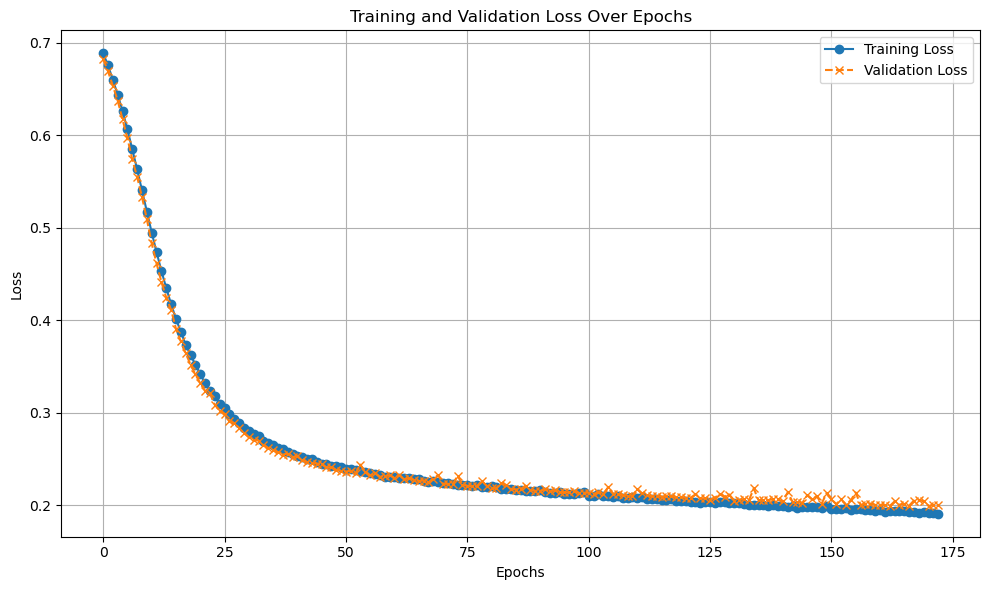

In [21]:
import matplotlib.pyplot as plt
def plot_losses(train_losses, val_losses):
    """
    Plot training and validation losses.

    :param train_losses: List of training loss values
    :param val_losses: List of validation loss values
    """
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label="Training Loss", linestyle='-', marker='o')
    plt.plot(val_losses, label="Validation Loss", linestyle='--', marker='x')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Over Epochs")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_losses(train_losses, val_losses)

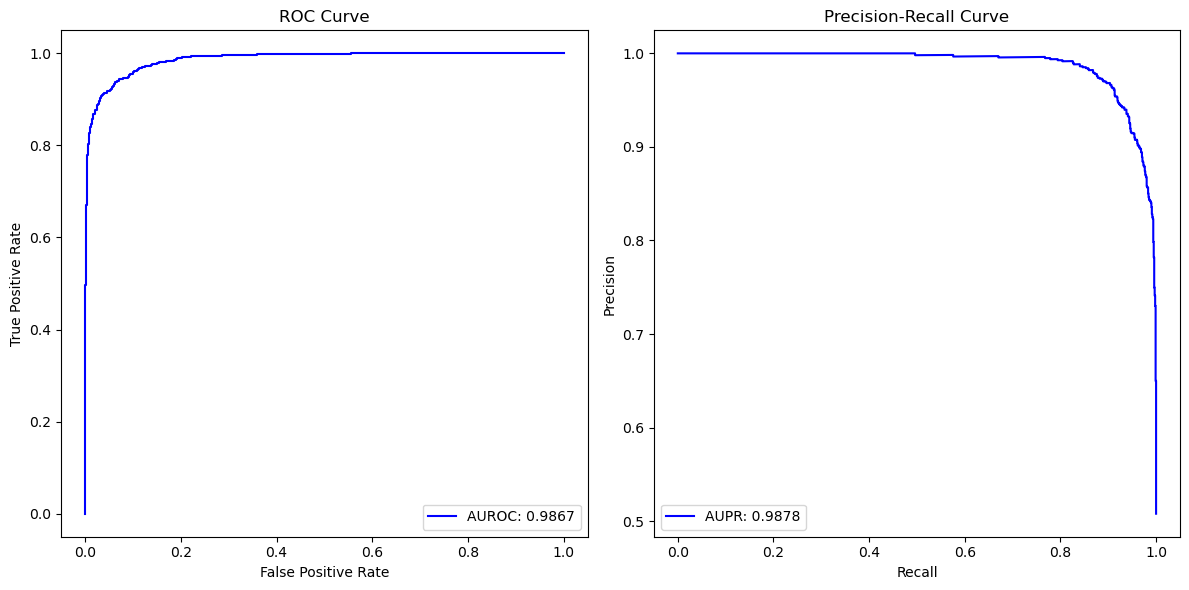

ROC AUC: 0.9867, PR AUC: 0.9878


In [14]:
import matplotlib.pyplot as plt

# For ROC and PR curve calculations
from sklearn.metrics import roc_curve, auc, precision_recall_curve
# Evaluate the model on the validation set and get predictions
# Evaluate the model on the validation set
all_outputs, all_labels = [], []
trainer.model.eval()  # Set model to evaluation mode

with torch.no_grad():
    for embeddings, labels in trainer.data_splits.val_loader:
        embeddings, labels = embeddings.to(device), labels.float().to(device)

        # Generate the mask
        mask = (embeddings != 0).bool()

        # Model predictions with mask
        outputs = trainer.model(embeddings, mask)
        all_outputs.extend(outputs.cpu().numpy().flatten())  # Flatten to 1D array
        all_labels.extend(labels.cpu().numpy())

# Function to plot ROC and PR curves
def roc_pr(outputs, labels, plot='yes'):
    fpr, tpr, _ = roc_curve(np.array(labels), np.array(outputs))
    pre, rec, _ = precision_recall_curve(np.array(labels), np.array(outputs))

    if plot == 'yes':
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
        
        # ROC Curve
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, color='b', label=f'AUROC: {roc_auc:.4f}')
        ax1.set_title('ROC Curve')
        ax1.set_xlabel('False Positive Rate')
        ax1.set_ylabel('True Positive Rate')
        ax1.legend(loc="lower right")

        # Precision-Recall Curve
        pr_auc = auc(rec, pre)
        ax2.plot(rec, pre, color='b', label=f'AUPR: {pr_auc:.4f}')
        ax2.set_title('Precision-Recall Curve')
        ax2.set_xlabel('Recall')
        ax2.set_ylabel('Precision')
        ax2.legend(loc="lower left")

        plt.tight_layout()
        plt.show()

    return roc_auc, pr_auc

# Plot ROC and PR curves
roc_auc, pr_auc = roc_pr(all_outputs, all_labels, plot='yes')
print(f"ROC AUC: {roc_auc:.4f}, PR AUC: {pr_auc:.4f}")

In [15]:
import pickle

# Replace with the actual path to your pickle file
pickle_file_path = r"R:\Kevin\Projects\trend-analysis\embeddings\mar_beta0.1_stella_emb.pickle"

# Load the pickle file
with open(pickle_file_path, 'rb') as handle:
   mar_embeddings = pickle.load(handle)

In [16]:

input_dim = 1536  # Assuming embeddings have 1536 dimensions
hidden_dim = 128
output_dim = 1
model_type = 'mlp'  # Example: Using an MLP model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize Training instance
trainer = Training(
    data=mar_embeddings,
    model=model_type,
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    device=device
)

# Train the model
best_model, train_losses, val_losses = trainer.training(lr=0.0001, num_epochs=1000, patience=10)

Epoch [1/1000], Train Loss: 0.6895
Epoch [1/1000], Val Loss: 0.6850
Epoch [2/1000], Train Loss: 0.6786
Epoch [2/1000], Val Loss: 0.6748
Epoch [3/1000], Train Loss: 0.6637
Epoch [3/1000], Val Loss: 0.6597
Epoch [4/1000], Train Loss: 0.6478
Epoch [4/1000], Val Loss: 0.6399
Epoch [5/1000], Train Loss: 0.6294
Epoch [5/1000], Val Loss: 0.6199
Epoch [6/1000], Train Loss: 0.6088
Epoch [6/1000], Val Loss: 0.5984
Epoch [7/1000], Train Loss: 0.5861
Epoch [7/1000], Val Loss: 0.5757
Epoch [8/1000], Train Loss: 0.5627
Epoch [8/1000], Val Loss: 0.5519
Epoch [9/1000], Train Loss: 0.5393
Epoch [9/1000], Val Loss: 0.5321
Epoch [10/1000], Train Loss: 0.5168
Epoch [10/1000], Val Loss: 0.5081
Epoch [11/1000], Train Loss: 0.4950
Epoch [11/1000], Val Loss: 0.4855
Epoch [12/1000], Train Loss: 0.4738
Epoch [12/1000], Val Loss: 0.4667
Epoch [13/1000], Train Loss: 0.4570
Epoch [13/1000], Val Loss: 0.4562
Epoch [14/1000], Train Loss: 0.4389
Epoch [14/1000], Val Loss: 0.4324
Epoch [15/1000], Train Loss: 0.4233
Ep

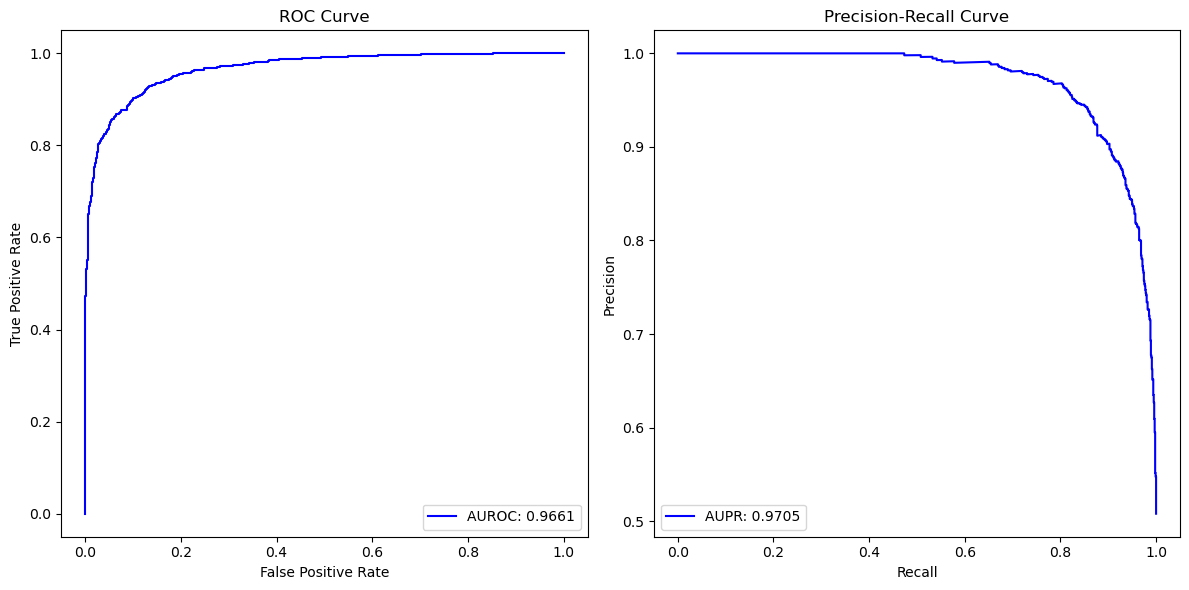

ROC AUC: 0.9661, PR AUC: 0.9705


In [17]:
import matplotlib.pyplot as plt

# For ROC and PR curve calculations
from sklearn.metrics import roc_curve, auc, precision_recall_curve
# Evaluate the model on the validation set and get predictions
# Evaluate the model on the validation set
all_outputs, all_labels = [], []
trainer.model.eval()  # Set model to evaluation mode

with torch.no_grad():
    for embeddings, labels in trainer.data_splits.val_loader:
        embeddings, labels = embeddings.to(device), labels.float().to(device)

        # Generate the mask
        mask = (embeddings != 0).bool()

        # Model predictions with mask
        outputs = trainer.model(embeddings, mask)
        all_outputs.extend(outputs.cpu().numpy().flatten())  # Flatten to 1D array
        all_labels.extend(labels.cpu().numpy())

# Function to plot ROC and PR curves
def roc_pr(outputs, labels, plot='yes'):
    fpr, tpr, _ = roc_curve(np.array(labels), np.array(outputs))
    pre, rec, _ = precision_recall_curve(np.array(labels), np.array(outputs))

    if plot == 'yes':
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
        
        # ROC Curve
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, color='b', label=f'AUROC: {roc_auc:.4f}')
        ax1.set_title('ROC Curve')
        ax1.set_xlabel('False Positive Rate')
        ax1.set_ylabel('True Positive Rate')
        ax1.legend(loc="lower right")

        # Precision-Recall Curve
        pr_auc = auc(rec, pre)
        ax2.plot(rec, pre, color='b', label=f'AUPR: {pr_auc:.4f}')
        ax2.set_title('Precision-Recall Curve')
        ax2.set_xlabel('Recall')
        ax2.set_ylabel('Precision')
        ax2.legend(loc="lower left")

        plt.tight_layout()
        plt.show()

    return roc_auc, pr_auc

# Plot ROC and PR curves
roc_auc, pr_auc = roc_pr(all_outputs, all_labels, plot='yes')
print(f"ROC AUC: {roc_auc:.4f}, PR AUC: {pr_auc:.4f}")

In [18]:
import pickle

# Replace with the actual path to your pickle file
pickle_file_path = r"R:\Kevin\Projects\trend-analysis\embeddings\mcar_beta0.1_stella_emb.pickle"

# Load the pickle file
with open(pickle_file_path, 'rb') as handle:
   mcar_embeddings = pickle.load(handle)

In [19]:

input_dim = 1536  # Assuming embeddings have 1536 dimensions
hidden_dim = 128
output_dim = 1
model_type = 'mlp'  # Example: Using an MLP model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize Training instance
trainer = Training(
    data=mcar_embeddings,
    model=model_type,
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    device=device
)

# Train the model
best_model, train_losses, val_losses = trainer.training(lr=0.0001, num_epochs=1000, patience=10)

Epoch [1/1000], Train Loss: 0.6887
Epoch [1/1000], Val Loss: 0.6826
Epoch [2/1000], Train Loss: 0.6757
Epoch [2/1000], Val Loss: 0.6694
Epoch [3/1000], Train Loss: 0.6601
Epoch [3/1000], Val Loss: 0.6536
Epoch [4/1000], Train Loss: 0.6440
Epoch [4/1000], Val Loss: 0.6376
Epoch [5/1000], Train Loss: 0.6261
Epoch [5/1000], Val Loss: 0.6175
Epoch [6/1000], Train Loss: 0.6064
Epoch [6/1000], Val Loss: 0.5969
Epoch [7/1000], Train Loss: 0.5849
Epoch [7/1000], Val Loss: 0.5740
Epoch [8/1000], Train Loss: 0.5633
Epoch [8/1000], Val Loss: 0.5552
Epoch [9/1000], Train Loss: 0.5405
Epoch [9/1000], Val Loss: 0.5333
Epoch [10/1000], Train Loss: 0.5177
Epoch [10/1000], Val Loss: 0.5094
Epoch [11/1000], Train Loss: 0.4950
Epoch [11/1000], Val Loss: 0.4833
Epoch [12/1000], Train Loss: 0.4738
Epoch [12/1000], Val Loss: 0.4616
Epoch [13/1000], Train Loss: 0.4535
Epoch [13/1000], Val Loss: 0.4416
Epoch [14/1000], Train Loss: 0.4350
Epoch [14/1000], Val Loss: 0.4245
Epoch [15/1000], Train Loss: 0.4175
Ep

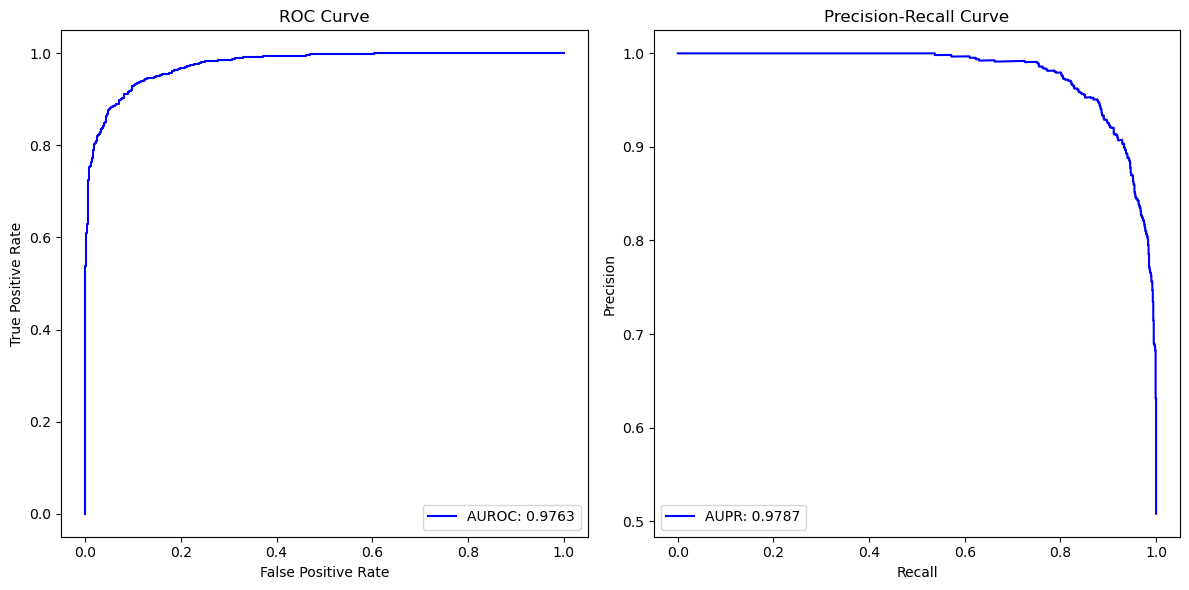

ROC AUC: 0.9763, PR AUC: 0.9787


In [20]:
import matplotlib.pyplot as plt

# For ROC and PR curve calculations
from sklearn.metrics import roc_curve, auc, precision_recall_curve
# Evaluate the model on the validation set and get predictions
# Evaluate the model on the validation set
all_outputs, all_labels = [], []
trainer.model.eval()  # Set model to evaluation mode

with torch.no_grad():
    for embeddings, labels in trainer.data_splits.val_loader:
        embeddings, labels = embeddings.to(device), labels.float().to(device)

        # Generate the mask
        mask = (embeddings != 0).bool()

        # Model predictions with mask
        outputs = trainer.model(embeddings, mask)
        all_outputs.extend(outputs.cpu().numpy().flatten())  # Flatten to 1D array
        all_labels.extend(labels.cpu().numpy())

# Function to plot ROC and PR curves
def roc_pr(outputs, labels, plot='yes'):
    fpr, tpr, _ = roc_curve(np.array(labels), np.array(outputs))
    pre, rec, _ = precision_recall_curve(np.array(labels), np.array(outputs))

    if plot == 'yes':
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
        
        # ROC Curve
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, color='b', label=f'AUROC: {roc_auc:.4f}')
        ax1.set_title('ROC Curve')
        ax1.set_xlabel('False Positive Rate')
        ax1.set_ylabel('True Positive Rate')
        ax1.legend(loc="lower right")

        # Precision-Recall Curve
        pr_auc = auc(rec, pre)
        ax2.plot(rec, pre, color='b', label=f'AUPR: {pr_auc:.4f}')
        ax2.set_title('Precision-Recall Curve')
        ax2.set_xlabel('Recall')
        ax2.set_ylabel('Precision')
        ax2.legend(loc="lower left")

        plt.tight_layout()
        plt.show()

    return roc_auc, pr_auc

# Plot ROC and PR curves
roc_auc, pr_auc = roc_pr(all_outputs, all_labels, plot='yes')
print(f"ROC AUC: {roc_auc:.4f}, PR AUC: {pr_auc:.4f}")

In [34]:
# Define input parameters
input_dim = 1536  # Assuming embeddings have 1536 dimensions
hidden_dim = 128
output_dim = 1
model_type = 'lr'  # Example: Using an MLP model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize Training instance
trainer = Training(
    data=noise_emb,
    model=model_type,
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    device=device
)

# Train the model
best_model, train_losses, val_losses = trainer.training(lr=0.001, num_epochs=1000, patience=10)

Epoch [1/1000], Train Loss: 0.6740
Epoch [1/1000], Val Loss: 0.6578
Epoch [2/1000], Train Loss: 0.6462
Epoch [2/1000], Val Loss: 0.6367
Epoch [3/1000], Train Loss: 0.6258
Epoch [3/1000], Val Loss: 0.6177
Epoch [4/1000], Train Loss: 0.6079
Epoch [4/1000], Val Loss: 0.6011
Epoch [5/1000], Train Loss: 0.5910
Epoch [5/1000], Val Loss: 0.5849
Epoch [6/1000], Train Loss: 0.5753
Epoch [6/1000], Val Loss: 0.5690
Epoch [7/1000], Train Loss: 0.5604
Epoch [7/1000], Val Loss: 0.5548
Epoch [8/1000], Train Loss: 0.5464
Epoch [8/1000], Val Loss: 0.5410
Epoch [9/1000], Train Loss: 0.5330
Epoch [9/1000], Val Loss: 0.5283
Epoch [10/1000], Train Loss: 0.5202
Epoch [10/1000], Val Loss: 0.5160
Epoch [11/1000], Train Loss: 0.5085
Epoch [11/1000], Val Loss: 0.5045
Epoch [12/1000], Train Loss: 0.4971
Epoch [12/1000], Val Loss: 0.4945
Epoch [13/1000], Train Loss: 0.4868
Epoch [13/1000], Val Loss: 0.4837
Epoch [14/1000], Train Loss: 0.4763
Epoch [14/1000], Val Loss: 0.4735
Epoch [15/1000], Train Loss: 0.4669
Ep

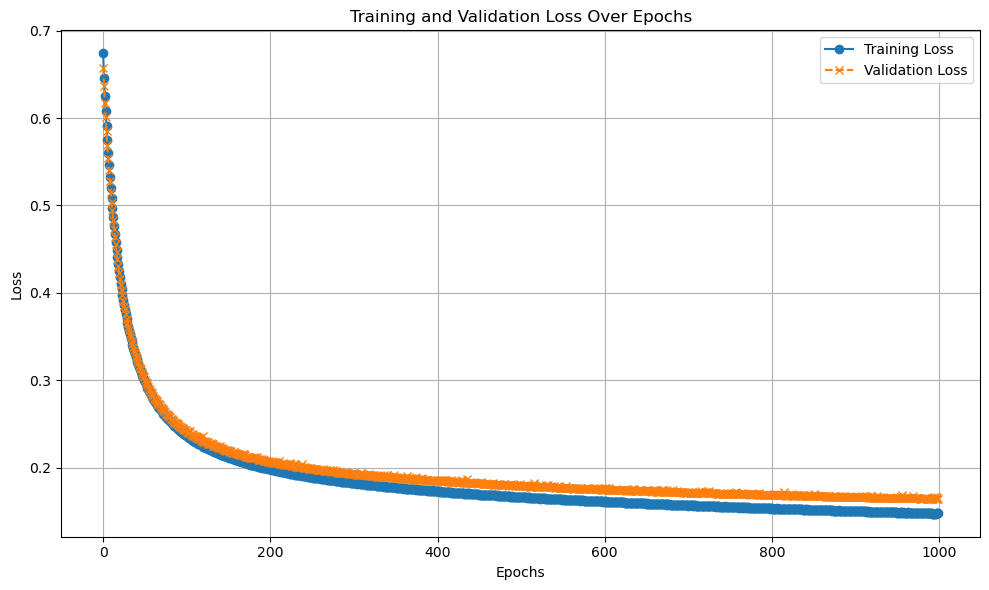

In [35]:
# Call the plotting function
plot_losses(train_losses, val_losses)

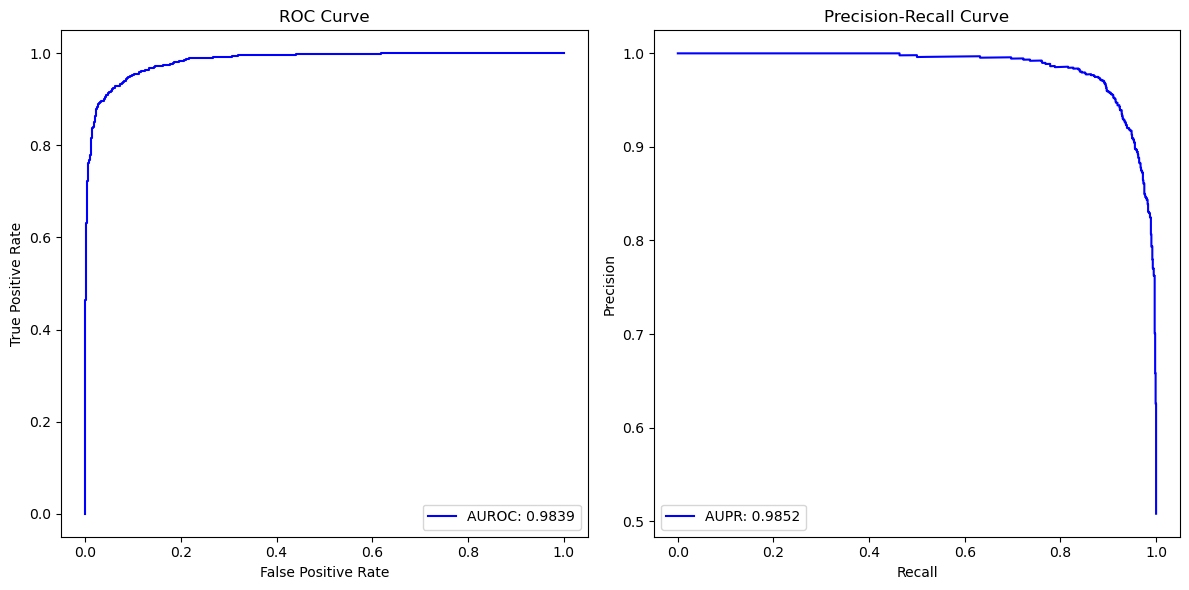

ROC AUC: 0.9839, PR AUC: 0.9852


In [36]:
import matplotlib.pyplot as plt

# For ROC and PR curve calculations
from sklearn.metrics import roc_curve, auc, precision_recall_curve
# Evaluate the model on the validation set and get predictions
# Evaluate the model on the validation set
all_outputs, all_labels = [], []
trainer.model.eval()  # Set model to evaluation mode

with torch.no_grad():
    for embeddings, labels in trainer.data_splits.val_loader:
        embeddings, labels = embeddings.to(device), labels.float().to(device)

        # Generate the mask
        mask = (embeddings != 0).bool()

        # Model predictions with mask
        outputs = trainer.model(embeddings, mask)
        all_outputs.extend(outputs.cpu().numpy().flatten())  # Flatten to 1D array
        all_labels.extend(labels.cpu().numpy())

# Function to plot ROC and PR curves
def roc_pr(outputs, labels, plot='yes'):
    fpr, tpr, _ = roc_curve(np.array(labels), np.array(outputs))
    pre, rec, _ = precision_recall_curve(np.array(labels), np.array(outputs))

    if plot == 'yes':
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
        
        # ROC Curve
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, color='b', label=f'AUROC: {roc_auc:.4f}')
        ax1.set_title('ROC Curve')
        ax1.set_xlabel('False Positive Rate')
        ax1.set_ylabel('True Positive Rate')
        ax1.legend(loc="lower right")

        # Precision-Recall Curve
        pr_auc = auc(rec, pre)
        ax2.plot(rec, pre, color='b', label=f'AUPR: {pr_auc:.4f}')
        ax2.set_title('Precision-Recall Curve')
        ax2.set_xlabel('Recall')
        ax2.set_ylabel('Precision')
        ax2.legend(loc="lower left")

        plt.tight_layout()
        plt.show()

    return roc_auc, pr_auc

# Plot ROC and PR curves
roc_auc, pr_auc = roc_pr(all_outputs, all_labels, plot='yes')
print(f"ROC AUC: {roc_auc:.4f}, PR AUC: {pr_auc:.4f}")

In [28]:
# Define input parameters
input_dim = 1536  # Assuming embeddings have 1536 dimensions
hidden_dim = 128
output_dim = 1
model_type = 'lr'  # Example: Using an MLP model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize Training instance
trainer = Training(
    data=mar_embeddings,
    model=model_type,
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    device=device
)

# Train the model
best_model, train_losses, val_losses = trainer.training(lr=0.001, num_epochs=1000, patience=10)

Epoch [1/1000], Train Loss: 0.6835
Epoch [1/1000], Val Loss: 0.6746
Epoch [2/1000], Train Loss: 0.6674
Epoch [2/1000], Val Loss: 0.6606
Epoch [3/1000], Train Loss: 0.6539
Epoch [3/1000], Val Loss: 0.6483
Epoch [4/1000], Train Loss: 0.6421
Epoch [4/1000], Val Loss: 0.6370
Epoch [5/1000], Train Loss: 0.6303
Epoch [5/1000], Val Loss: 0.6270
Epoch [6/1000], Train Loss: 0.6201
Epoch [6/1000], Val Loss: 0.6158
Epoch [7/1000], Train Loss: 0.6099
Epoch [7/1000], Val Loss: 0.6066
Epoch [8/1000], Train Loss: 0.6006
Epoch [8/1000], Val Loss: 0.5969
Epoch [9/1000], Train Loss: 0.5912
Epoch [9/1000], Val Loss: 0.5875
Epoch [10/1000], Train Loss: 0.5818
Epoch [10/1000], Val Loss: 0.5790
Epoch [11/1000], Train Loss: 0.5735
Epoch [11/1000], Val Loss: 0.5704
Epoch [12/1000], Train Loss: 0.5658
Epoch [12/1000], Val Loss: 0.5633
Epoch [13/1000], Train Loss: 0.5572
Epoch [13/1000], Val Loss: 0.5549
Epoch [14/1000], Train Loss: 0.5503
Epoch [14/1000], Val Loss: 0.5472
Epoch [15/1000], Train Loss: 0.5427
Ep

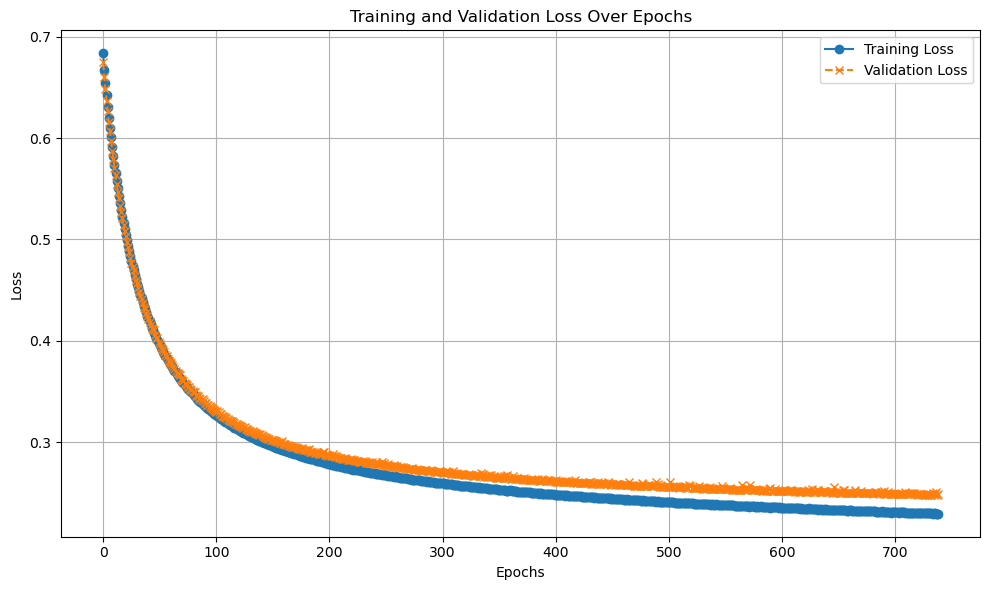

In [29]:
# Call the plotting function
plot_losses(train_losses, val_losses)

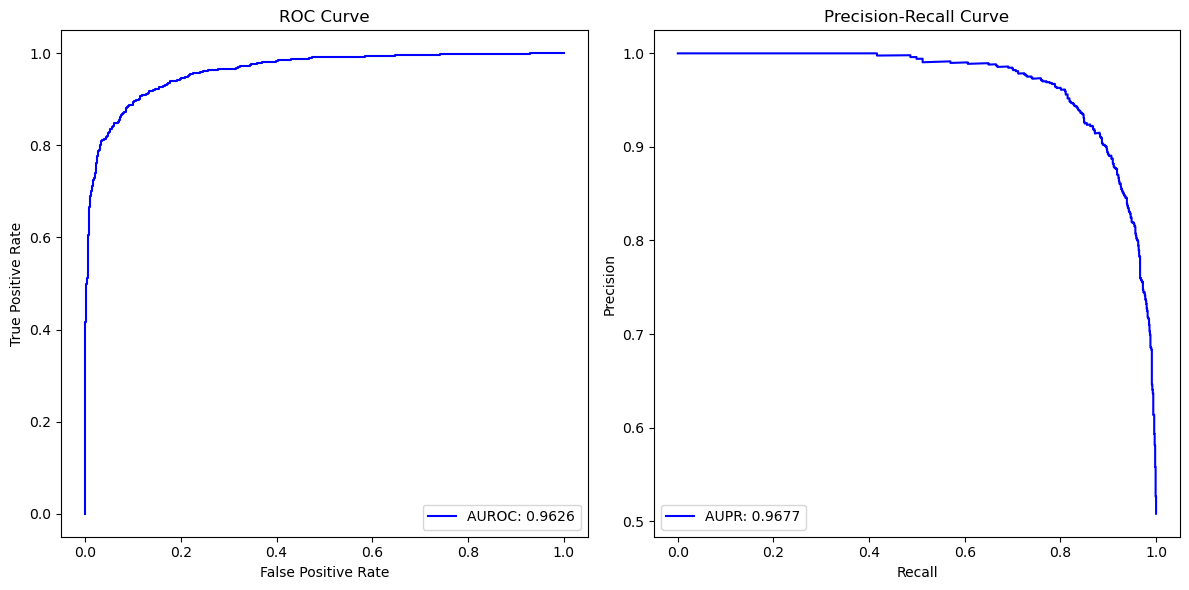

ROC AUC: 0.9626, PR AUC: 0.9677


In [30]:
import matplotlib.pyplot as plt

# For ROC and PR curve calculations
from sklearn.metrics import roc_curve, auc, precision_recall_curve
# Evaluate the model on the validation set and get predictions
# Evaluate the model on the validation set
all_outputs, all_labels = [], []
trainer.model.eval()  # Set model to evaluation mode

with torch.no_grad():
    for embeddings, labels in trainer.data_splits.val_loader:
        embeddings, labels = embeddings.to(device), labels.float().to(device)

        # Generate the mask
        mask = (embeddings != 0).bool()

        # Model predictions with mask
        outputs = trainer.model(embeddings, mask)
        all_outputs.extend(outputs.cpu().numpy().flatten())  # Flatten to 1D array
        all_labels.extend(labels.cpu().numpy())

# Function to plot ROC and PR curves
def roc_pr(outputs, labels, plot='yes'):
    fpr, tpr, _ = roc_curve(np.array(labels), np.array(outputs))
    pre, rec, _ = precision_recall_curve(np.array(labels), np.array(outputs))

    if plot == 'yes':
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
        
        # ROC Curve
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, color='b', label=f'AUROC: {roc_auc:.4f}')
        ax1.set_title('ROC Curve')
        ax1.set_xlabel('False Positive Rate')
        ax1.set_ylabel('True Positive Rate')
        ax1.legend(loc="lower right")

        # Precision-Recall Curve
        pr_auc = auc(rec, pre)
        ax2.plot(rec, pre, color='b', label=f'AUPR: {pr_auc:.4f}')
        ax2.set_title('Precision-Recall Curve')
        ax2.set_xlabel('Recall')
        ax2.set_ylabel('Precision')
        ax2.legend(loc="lower left")

        plt.tight_layout()
        plt.show()

    return roc_auc, pr_auc

# Plot ROC and PR curves
roc_auc, pr_auc = roc_pr(all_outputs, all_labels, plot='yes')
print(f"ROC AUC: {roc_auc:.4f}, PR AUC: {pr_auc:.4f}")

In [31]:
# Define input parameters
input_dim = 1536  # Assuming embeddings have 1536 dimensions
hidden_dim = 128
output_dim = 1
model_type = 'lr'  # Example: Using an MLP model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize Training instance
trainer = Training(
    data=mcar_embeddings,
    model=model_type,
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    device=device
)

# Train the model
best_model, train_losses, val_losses = trainer.training(lr=0.001, num_epochs=1000, patience=10)

Epoch [1/1000], Train Loss: 0.6828
Epoch [1/1000], Val Loss: 0.6716
Epoch [2/1000], Train Loss: 0.6638
Epoch [2/1000], Val Loss: 0.6566
Epoch [3/1000], Train Loss: 0.6502
Epoch [3/1000], Val Loss: 0.6437
Epoch [4/1000], Train Loss: 0.6378
Epoch [4/1000], Val Loss: 0.6322
Epoch [5/1000], Train Loss: 0.6259
Epoch [5/1000], Val Loss: 0.6205
Epoch [6/1000], Train Loss: 0.6152
Epoch [6/1000], Val Loss: 0.6099
Epoch [7/1000], Train Loss: 0.6046
Epoch [7/1000], Val Loss: 0.5997
Epoch [8/1000], Train Loss: 0.5951
Epoch [8/1000], Val Loss: 0.5900
Epoch [9/1000], Train Loss: 0.5860
Epoch [9/1000], Val Loss: 0.5825
Epoch [10/1000], Train Loss: 0.5772
Epoch [10/1000], Val Loss: 0.5723
Epoch [11/1000], Train Loss: 0.5674
Epoch [11/1000], Val Loss: 0.5642
Epoch [12/1000], Train Loss: 0.5598
Epoch [12/1000], Val Loss: 0.5558
Epoch [13/1000], Train Loss: 0.5518
Epoch [13/1000], Val Loss: 0.5472
Epoch [14/1000], Train Loss: 0.5438
Epoch [14/1000], Val Loss: 0.5430
Epoch [15/1000], Train Loss: 0.5368
Ep

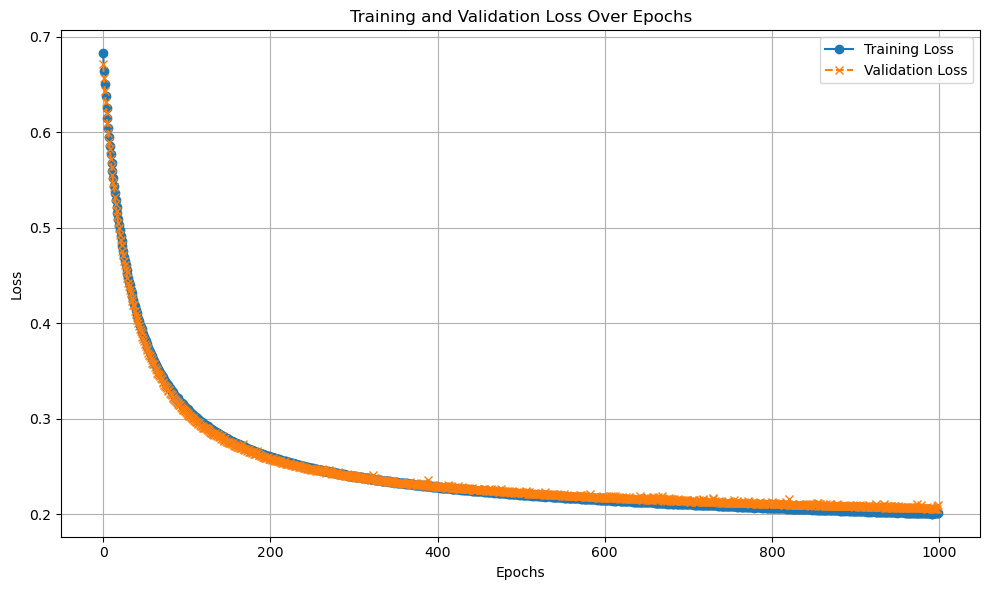

In [32]:
# Call the plotting function
plot_losses(train_losses, val_losses)

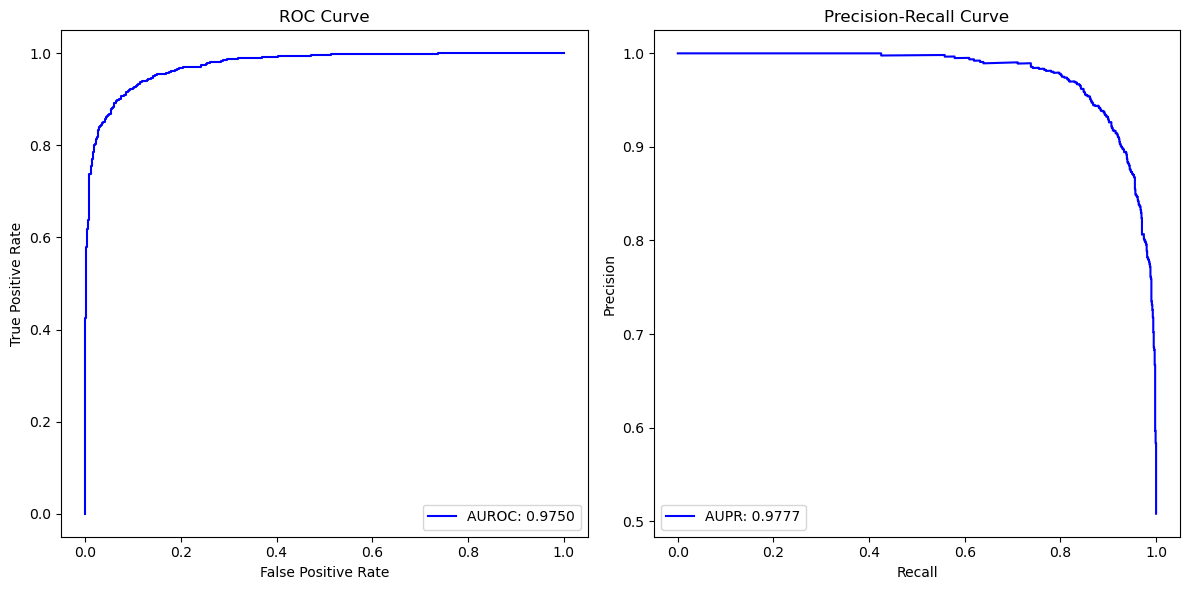

ROC AUC: 0.9750, PR AUC: 0.9777


In [33]:
import matplotlib.pyplot as plt

# For ROC and PR curve calculations
from sklearn.metrics import roc_curve, auc, precision_recall_curve
# Evaluate the model on the validation set and get predictions
# Evaluate the model on the validation set
all_outputs, all_labels = [], []
trainer.model.eval()  # Set model to evaluation mode

with torch.no_grad():
    for embeddings, labels in trainer.data_splits.val_loader:
        embeddings, labels = embeddings.to(device), labels.float().to(device)

        # Generate the mask
        mask = (embeddings != 0).bool()

        # Model predictions with mask
        outputs = trainer.model(embeddings, mask)
        all_outputs.extend(outputs.cpu().numpy().flatten())  # Flatten to 1D array
        all_labels.extend(labels.cpu().numpy())

# Function to plot ROC and PR curves
def roc_pr(outputs, labels, plot='yes'):
    fpr, tpr, _ = roc_curve(np.array(labels), np.array(outputs))
    pre, rec, _ = precision_recall_curve(np.array(labels), np.array(outputs))

    if plot == 'yes':
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
        
        # ROC Curve
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, color='b', label=f'AUROC: {roc_auc:.4f}')
        ax1.set_title('ROC Curve')
        ax1.set_xlabel('False Positive Rate')
        ax1.set_ylabel('True Positive Rate')
        ax1.legend(loc="lower right")

        # Precision-Recall Curve
        pr_auc = auc(rec, pre)
        ax2.plot(rec, pre, color='b', label=f'AUPR: {pr_auc:.4f}')
        ax2.set_title('Precision-Recall Curve')
        ax2.set_xlabel('Recall')
        ax2.set_ylabel('Precision')
        ax2.legend(loc="lower left")

        plt.tight_layout()
        plt.show()

    return roc_auc, pr_auc

# Plot ROC and PR curves
roc_auc, pr_auc = roc_pr(all_outputs, all_labels, plot='yes')
print(f"ROC AUC: {roc_auc:.4f}, PR AUC: {pr_auc:.4f}")